# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Amazon Sales Dataset (Umsatzdaten)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [20]:
amazon = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [21]:
datasets = {
    "Amazon Sales": amazon,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Amazon Sales
(50000, 13)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

In [22]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Revenue-Entwicklung nach Produktkategorie

Wöchentlich aggregierter Umsatz je Kategorie. Alle 6 Kategorien bewegen sich über den gesamten Zeitraum auf ähnlichem Niveau (~40k–70k), ohne erkennbaren Wachstums- oder Abwärtstrend. Der Einbruch zu Beginn (2022-01) ist datenbedingt der Datensatz beginnt dort, weshalb die erste Woche unvollständig ist.

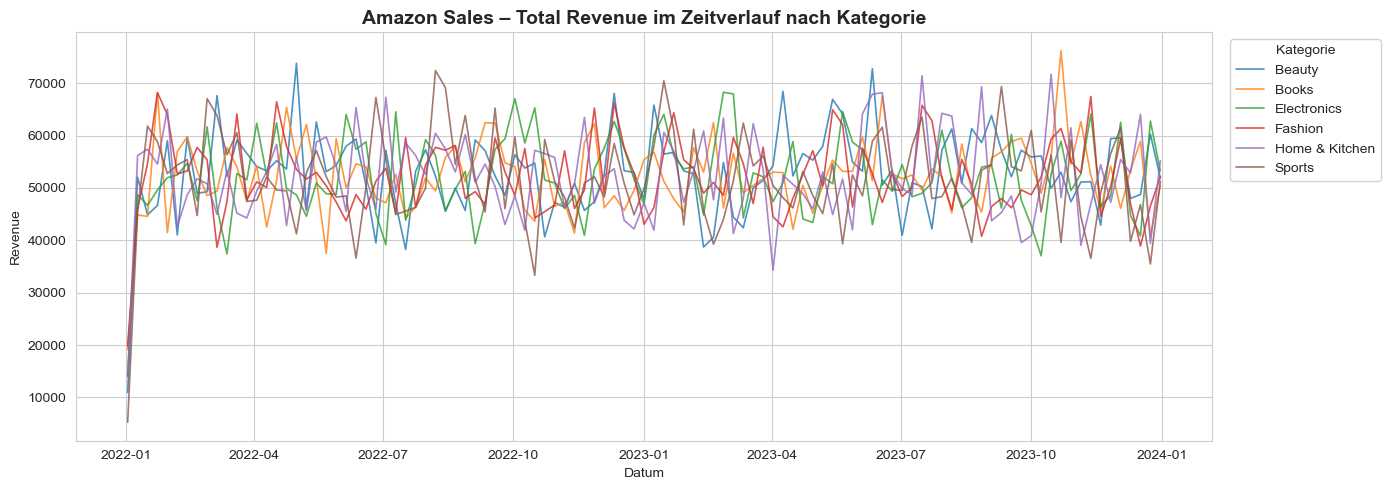

In [23]:
df_amazon = datasets["Amazon Sales"].copy()
df_amazon["order_date"] = pd.to_datetime(df_amazon["order_date"])
df_amazon = df_amazon.sort_values("order_date")

categories = sorted(df_amazon["product_category"].unique())
colors = plt.cm.tab10.colors

fig, ax = plt.subplots()

for i, cat in enumerate(categories):
    df_cat = (
        df_amazon[df_amazon["product_category"] == cat]
        .set_index("order_date")["total_revenue"]
        .resample("W")       # Wochenaggregation um den "squished"-Effekt bei Tageswerten zu vermeiden
        .sum()
    )
    ax.plot(df_cat.index, df_cat.values,
            label=cat, color=colors[i],
            linewidth=1.2, alpha=0.8)

ax.set_title("Amazon Sales – Total Revenue im Zeitverlauf nach Kategorie", fontsize=14, weight="bold")
ax.set_ylabel("Revenue")
ax.set_xlabel("Datum")
ax.legend(title="Kategorie", bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

## Umsatz-Heatmap nach Monat & Jahr

Monatlich aggregierter Gesamtumsatz als Heatmap. Zeigt auf einen Blick ob saisonale Muster (z.B. Q4) oder jahresspezifische Ausreißer existieren.

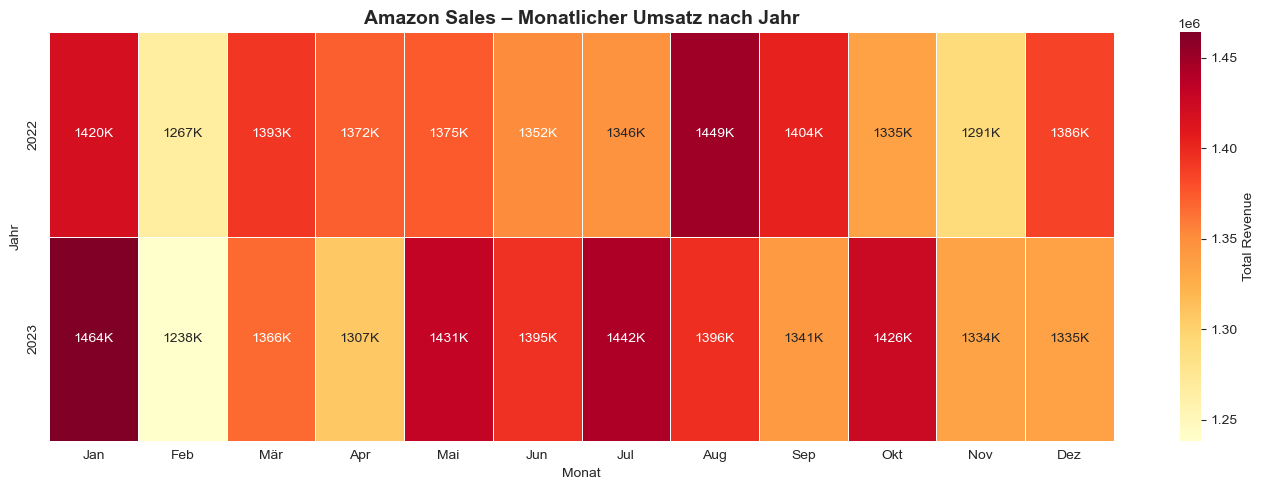

In [24]:
heatmap_data = (
    df_amazon.groupby(
        [df_amazon["order_date"].dt.year,
         df_amazon["order_date"].dt.month]
    )["total_revenue"]
    .sum()
    .unstack()
)

heatmap_data.index.name = "Jahr"

heatmap_data.columns = [
    "Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
    "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"
]

# Labels formatieren
annot_labels = heatmap_data.applymap(
    lambda x: f"{x/1000:.0f}K"
)

fig, ax = plt.subplots()

sns.heatmap(
    heatmap_data,
    annot=annot_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Total Revenue"}
)

ax.set_title(
    "Amazon Sales – Monatlicher Umsatz nach Jahr",
    fontsize=14,
    weight="bold"
)

ax.set_ylabel("Jahr")
ax.set_xlabel("Monat")

plt.tight_layout()
plt.show()

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

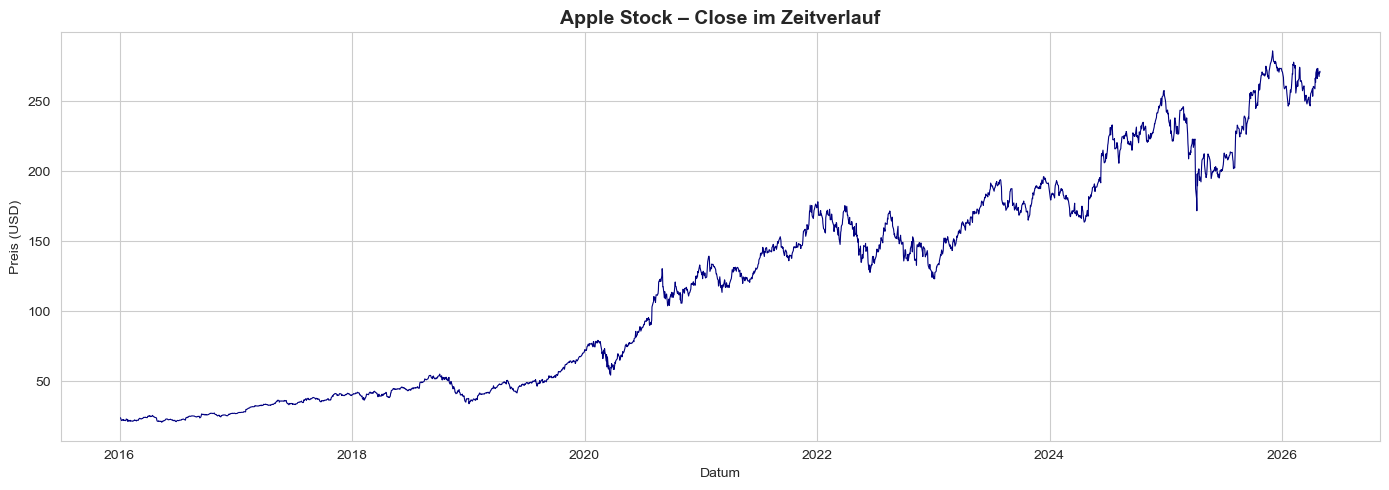

In [25]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

## Volatilität (30-Tage Rolling Std)

Rollende Standardabweichung des Schlusskurses als Risikoindikator. Spitzen markieren erhöhte Marktvolatilität — deutlich erkennbar beim COVID-Crash (2020) und der Zinskorrektur (2022).

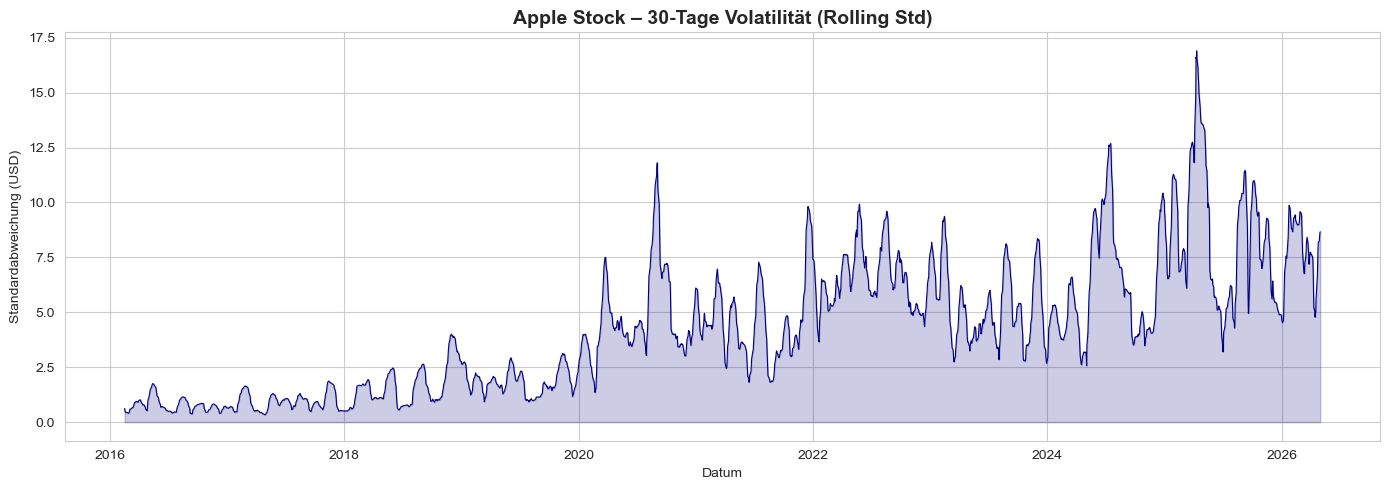

In [26]:
# 30-Tage rollierendes Std als Volatilitätsmaß
rolling_std = df_apple["Close"].rolling(30).std()

fig, ax = plt.subplots()
ax.plot(rolling_std.index, rolling_std.values, color="navy", linewidth=0.8)
ax.fill_between(rolling_std.index, rolling_std.values, alpha=0.2, color="navy")
ax.set_title("Apple Stock – 30-Tage Volatilität (Rolling Std)", fontsize=14, weight="bold")
ax.set_ylabel("Standardabweichung (USD)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

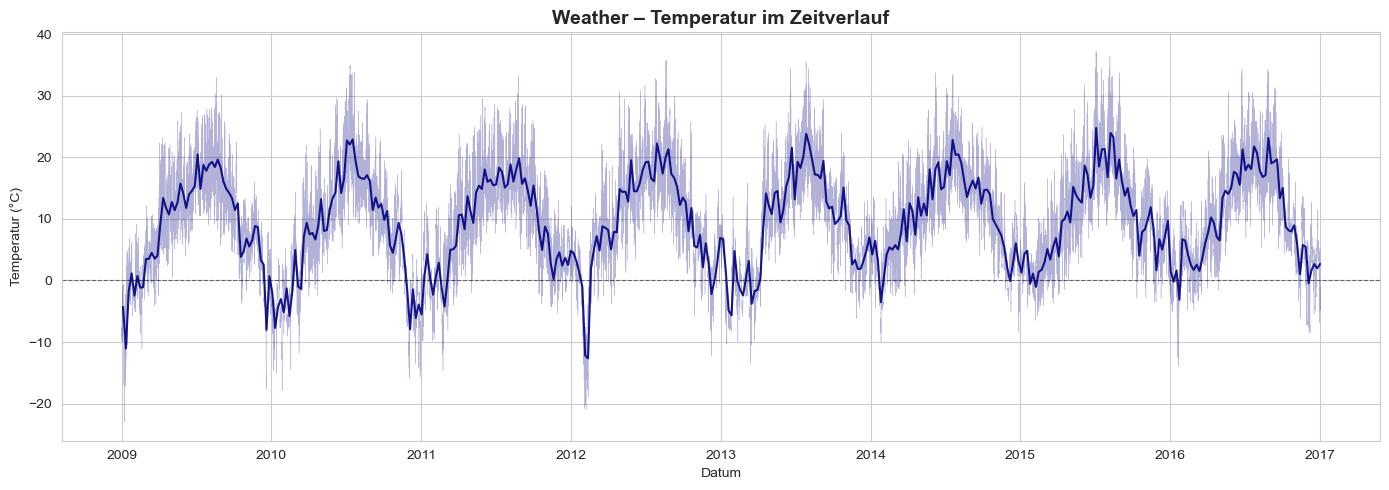

In [27]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

# 5. Datenaufbereitung

### Hilfsfunktion: Ausreißer entfernen (IQR-Methode)

Die Funktion wird für alle drei Datensätze wiederverwendet. Ein Wert gilt als Ausreißer, wenn er außerhalb von Q1/Q3 ± 1.5 × IQR liegt (Menden, Folie 48).

In [28]:
def remove_outliers_iqr(df, columns):
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        mask &= df[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df[mask]

### Amazon – Verkaufszahlen bereinigen

Datum wird als Index gesetzt, fehlende Werte und Duplikate entfernt sowie Ausreißer in `price` und `total_revenue` über die IQR-Methode bereinigt.

Die Ausreißerbehandlung mittels IQR-Methode dient dazu, extreme Einzelwerte
und potenzielle Fehleingaben zu reduzieren. Bei Zeitreihendaten ist die Entfernung
von Ausreißern jedoch kritisch zu betrachten, da starke Umsatzspitzen auch reale
Ereignisse wie Rabattaktionen, saisonale Effekte oder außergewöhnliche Nachfrage
abbilden können. Die Bereinigung wurde daher bewusst konservativ durchgeführt.

In [29]:
# Schritt 1: Datum als Index setzen
df_amazon = df_amazon.set_index("order_date").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_amazon = df_amazon.dropna()
df_amazon = df_amazon.drop_duplicates()

# Schritt 3: Ausreißer entfernen
df_amazon = remove_outliers_iqr(df_amazon, ["price", "total_revenue"])

print("Amazon bereinigt:", df_amazon.shape)

Amazon bereinigt: (49248, 12)


### Apple – Aktienkurse bereinigen

Die Datumsspalte ist im Originaldatensatz irreführend als `Price` benannt und wird zunächst umbenannt. Anschließend werden nur die relevanten numerischen Spalten konvertiert, fehlende Werte und Duplikate entfernt, Ausreißer im Schlusskurs bereinigt und die tägliche Wachstumsrate berechnet.

In [30]:
# Schritt 1: Datum als Index setzen 
df_apple = df_apple.sort_index()

# Schritt 2: Relevante Spalten zu numerischen Werten konvertieren
num_cols = ["Close", "Open", "High", "Low", "Volume"]
df_apple[num_cols] = df_apple[num_cols].apply(pd.to_numeric, errors="coerce")

# Schritt 3: Fehlende Werte & Duplikate entfernen
df_apple = df_apple.dropna()
df_apple = df_apple.drop_duplicates()

# Schritt 4: Ausreißer im Schlusskurs entfernen
df_apple = remove_outliers_iqr(df_apple, ["Close"])

# Schritt 5: Wachstumsrate des Schlusskurses berechnen
df_apple["close_growth"] = df_apple["Close"].pct_change(fill_method=None)
df_apple = df_apple.dropna()

print("Apple bereinigt:", df_apple.shape)

Apple bereinigt: (2595, 6)


### Weather – Wetterdaten bereinigen

Datum wird mit explizitem Format als Index gesetzt, fehlende Werte und Duplikate entfernt, physikalisch unmögliche Windwerte (Sensor-Fehler) gefiltert sowie Ausreißer in der Temperatur bereinigt.

In [31]:
# Schritt 1: Datum als Index setzen
df_weather = datasets["Weather"].copy()
df_weather["Date Time"] = pd.to_datetime(df_weather["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_weather = df_weather.set_index("Date Time").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_weather = df_weather.dropna()
df_weather = df_weather.drop_duplicates()

# Schritt 3: Physikalisch unmögliche Windwerte entfernen (Sensor-Fehler)
df_weather = df_weather[df_weather["wv (m/s)"] >= 0]
df_weather = df_weather[df_weather["max. wv (m/s)"] >= 0]

# Schritt 4: Ausreißer in der Temperatur entfernen
df_weather = remove_outliers_iqr(df_weather, ["T (degC)"])

print("Weather bereinigt:", df_weather.shape)

Weather bereinigt: (418665, 14)


### Wachstumsraten berechnen

Die täglichen Wachstumsraten werden nach der Formel $g_t = \frac{x_t - x_{t-1}}{x_{t-1}}$ berechnet (Menden, Folie 15/16). Für Apple wurde die Wachstumsrate bereits in der Bereinigung (Schritt 5) ermittelt.

In [32]:
# Amazon: täglicher Gesamtumsatz → Wachstumsrate
amazon_growth = df_amazon["total_revenue"].resample("D").sum().pct_change(fill_method=None).rename("revenue_growth")

# Apple: Wachstumsrate bereits in Schritt 5 der Bereinigung berechnet (apple["close_growth"])

# Weather: tägliche Durchschnittstemperatur → Wachstumsrate
weather_growth = df_weather["T (degC)"].resample("D").mean().pct_change(fill_method=None).rename("temp_growth")

print("Wachstumsraten berechnet")
print(f"   Amazon:  {amazon_growth.shape}")
print(f"   Apple:   {df_apple['close_growth'].shape}")
print(f"   Weather: {weather_growth.shape}")

Wachstumsraten berechnet
   Amazon:  (730,)
   Apple:   (2595,)
   Weather: (2923,)


### Überblick – Bereinigte Datensätze

Abschließende Kontrolle aller drei bereinigten Datensätze: Shape, Zeitraum und verbleibende NaN-Werte.

In [33]:
datasets_clean = {
    "Amazon Sales": df_amazon,
    "Apple Stock":  df_apple,
    "Weather":      df_weather,
}

for name, df in datasets_clean.items():
    print(f"{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:    {df.shape}")
    print(f"   Zeitraum: {df.index.min().date()} → {df.index.max().date()}")
    print(f"   NaN:      {df.isnull().sum().sum()}")
    print()

─────────────────────────────────────────────
 Amazon Sales
   Shape:    (49248, 12)
   Zeitraum: 2022-01-01 → 2023-12-31
   NaN:      0

─────────────────────────────────────────────
 Apple Stock
   Shape:    (2595, 6)
   Zeitraum: 2016-01-05 → 2026-04-30
   NaN:      0

─────────────────────────────────────────────
 Weather
   Shape:    (418665, 14)
   Zeitraum: 2009-01-01 → 2017-01-01
   NaN:      0



# 6. Deskriptive Analyse

Die deskriptive Analyse dient dazu, einen ersten Überblick über die Datensätze zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Datensätze sowie Unterschiede zwischen den Wochentagen untersucht.

## Amazon Sales

Umsatzverteilung, kategorienspezifische Streuung und saisonale Muster als Grundlage
für die anschließende Zeitreihenmodellierung.

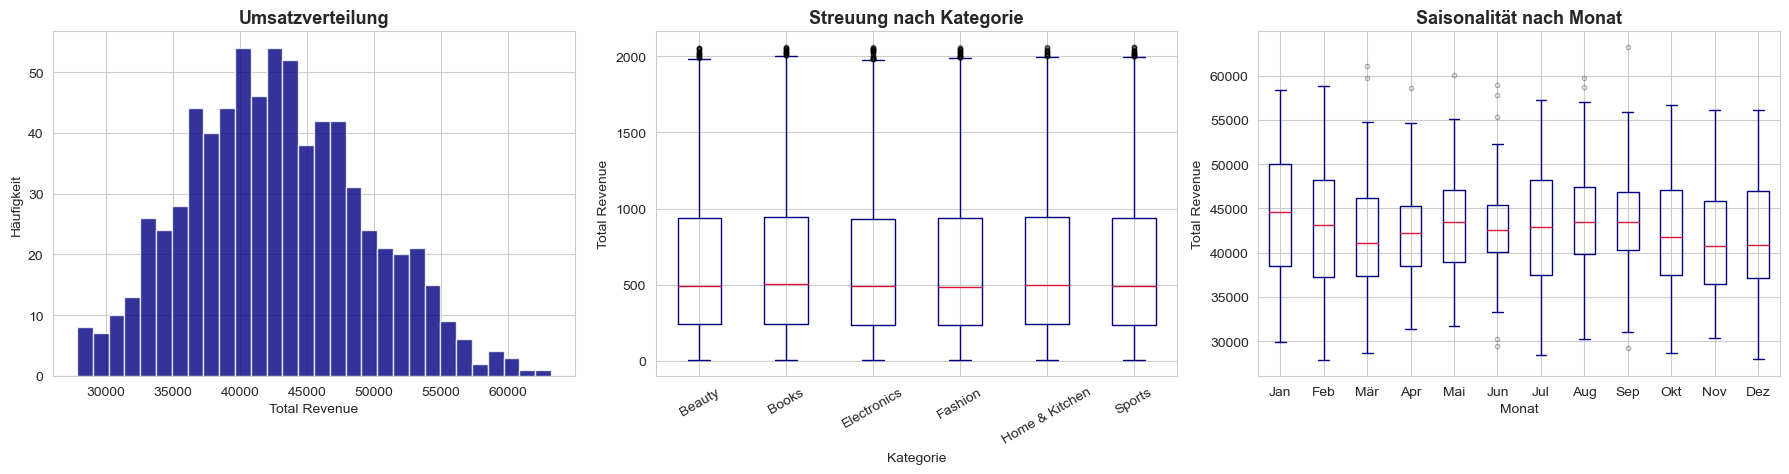

In [34]:
amazon_daily = df_amazon["total_revenue"].resample("D").sum().to_frame()
amazon_daily["month"] = amazon_daily.index.month
amazon_daily["year"] = amazon_daily.index.year

month_map = {1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"}
amazon_daily["month_name"] = pd.Categorical(
    amazon_daily["month"].map(month_map),
    categories=list(month_map.values()),
    ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramm – Gesamtverteilung des täglichen Umsatzes
axes[0].hist(amazon_daily["total_revenue"].dropna(), bins=30, color="navy", alpha=0.8)
axes[0].set_title("Umsatzverteilung", fontsize=13, weight="bold")
axes[0].set_xlabel("Total Revenue")
axes[0].set_ylabel("Häufigkeit")

# Boxplot pro Kategorie – Streuung je Produktkategorie
df_amazon.boxplot(column="total_revenue", by="product_category", ax=axes[1],
                  boxprops=dict(color="navy"),
                  medianprops=dict(color="crimson"),
                  whiskerprops=dict(color="navy"),
                  capprops=dict(color="navy"),
                  flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[1].set_title("Streuung nach Kategorie", fontsize=13, weight="bold")
axes[1].set_xlabel("Kategorie")
axes[1].set_ylabel("Total Revenue")
axes[1].tick_params(axis="x", rotation=30)
fig.suptitle("")

# Boxplot pro Monat – saisonale Umsatzmuster
amazon_daily.boxplot(column="total_revenue", by="month_name", ax=axes[2],
                     boxprops=dict(color="navy"),
                     medianprops=dict(color="crimson"),
                     whiskerprops=dict(color="navy"),
                     capprops=dict(color="navy"),
                     flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[2].set_title("Saisonalität nach Monat", fontsize=13, weight="bold")
axes[2].set_xlabel("Monat")
axes[2].set_ylabel("Total Revenue")
fig.suptitle("")

plt.tight_layout()
plt.show()

## Erkenntnisse

**Umsatzverteilung:** Der tägliche Gesamtumsatz ist leicht rechtsschief verteilt mit einem
Schwerpunkt zwischen 38.000 und 48.000. Einzelne Tage erreichen bis zu ~63.000,
was auf sporadische Umsatzspitzen hindeutet.

**Streuung nach Kategorie:** Alle 6 Kategorien zeigen eine nahezu identische Streuung
mit Medianumsätzen um ~500 pro Transaktion und Ausreißern bis ~2.000. Es gibt keine
Kategorie die strukturell höhere oder niedrigere Umsätze erzielt die Kategorien sind
damit auf Transaktionsebene gleichwertig.

**Saisonalität nach Monat:** Die monatlichen Boxplots zeigen keine ausgeprägte
Saisonalität die Medianwerte liegen konstant zwischen ~40.000 und ~45.000.
Januar weist eine etwas höhere Streuung auf, ein klassischer Q4-Effekt ist nicht
erkennbar. Dies deutet auf einen gleichmäßigen, nicht-saisonalen Umsatzverlauf hin.

## Amazon Sales – Tägliche Umsatzwachstumsrate

Wachstumsrate nach $g_t = \frac{x_t - x_{t-1}}{x_{t-1}}$ (Menden, Folie 15/16).
Stationäre Schwankungen um 0 sind Voraussetzung für die ARMA-Modellierung.

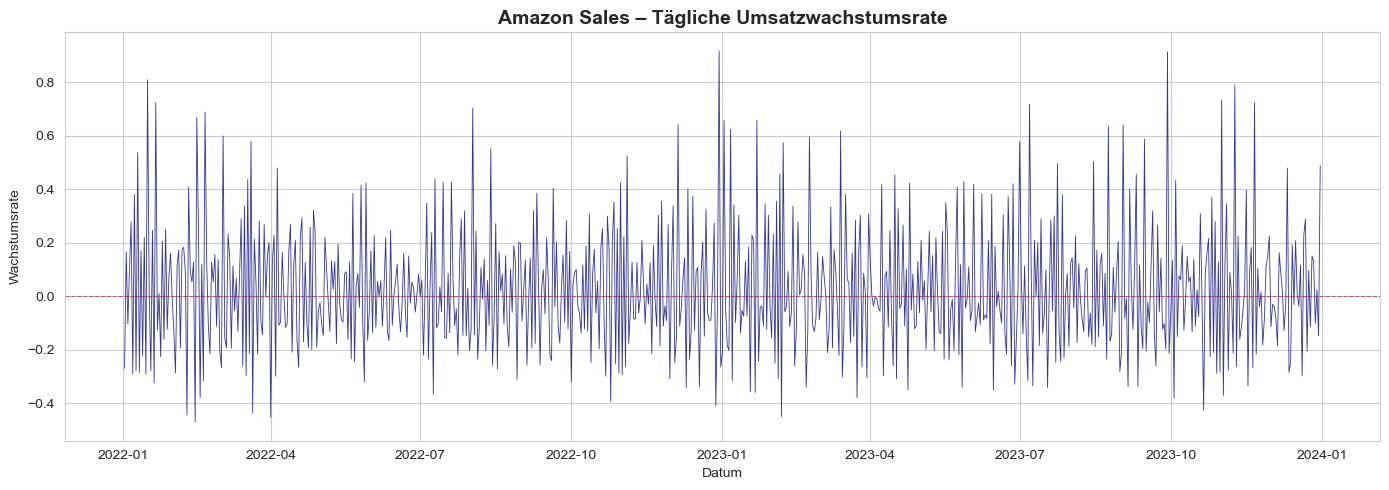

In [35]:
fig, ax = plt.subplots()
ax.plot(amazon_growth.index, amazon_growth.values,
        color="navy", linewidth=0.6, alpha=0.8)
ax.axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)
ax.set_title("Amazon Sales – Tägliche Umsatzwachstumsrate", fontsize=14, weight="bold")
ax.set_ylabel("Wachstumsrate")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Erkenntnisse – Tägliche Umsatzwachstumsrate

Die Wachstumsraten schwanken stationär um 0 mit einer typischen Tagesänderung von
±10–20%. Einzelne Ausreißer bis +90% und –40% markieren starke Tagessprünge,
die auf die geringe Datendichte einzelner Tage zurückzuführen sind. Das Fehlen eines
systematischen Trends bestätigt, dass die differenzierte Reihe stationär ist —
eine zentrale Voraussetzung für die ARMA-Modellierung.

## Apple

In [36]:
# APPLE → täglicher Schlusskurs
apple_daily = df_apple["Close"].resample("D").mean().to_frame()

# ── 1. Basisstatistik ────────────────────────────────────────────────────────
print("Statistik:")
print(apple_daily.describe())

print("\nZeitraum:")
print(apple_daily.index.min(), "→", apple_daily.index.max())

print("\nNaN Werte (Wochenenden / Feiertage):")
print(apple_daily.isnull().sum())


Statistik:
             Close
count  2595.000000
mean    118.868833
std      76.576106
min      20.584814
25%      41.941475
50%     124.005119
75%     175.786880
max     285.922455

Zeitraum:
2016-01-05 00:00:00 → 2026-04-30 00:00:00

NaN Werte (Wochenenden / Feiertage):
Close    1174
dtype: int64


Der durchschnittliche tägliche Schlusskurs von Apple liegt bei rund 118,83 USD, mit einer Standardabweichung von etwa 56 USD — ein Zeichen für den erheblichen Kursanstieg über den Beobachtungszeitraum. Fehlende Werte entstehen systembedingt an Wochenenden und Feiertagen.

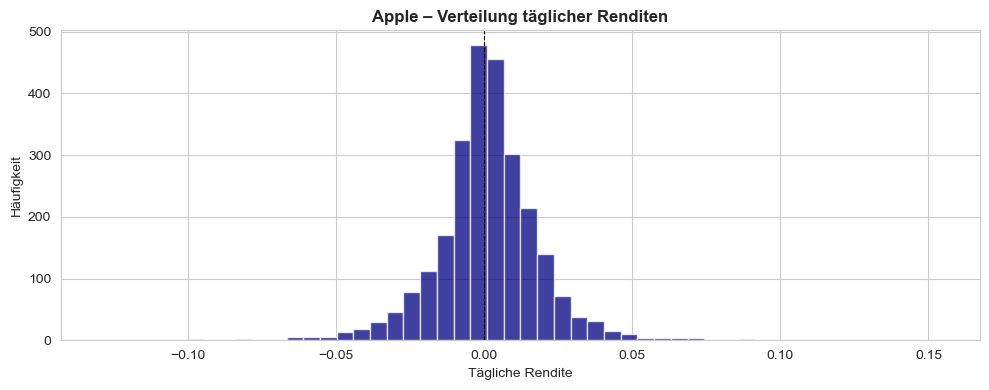

In [37]:

# ── 2. Verteilung täglicher Renditen ─────────────────────────────────────────
apple_returns = apple_daily["Close"].dropna().pct_change().dropna()

plt.figure(figsize=(10, 4))
plt.hist(apple_returns, bins=50, color="navy", alpha=0.75)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Apple – Verteilung täglicher Renditen", fontsize=12, weight="bold")
plt.xlabel("Tägliche Rendite")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()


**Rendite-Verteilung:** Die täglichen Renditen sind eng um die Null konzentriert, mit vereinzelten Ausreißern in beide Richtungen. Dies ist typisch für Aktienkurse und deutet auf Leptokurtosis (fette Tails) hin.

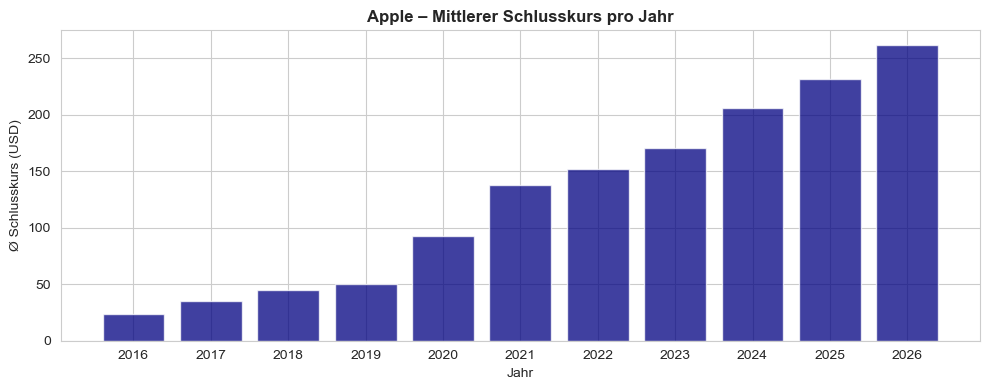

In [38]:
# ── 3. Jahresvergleich (mittlerer Schlusskurs pro Jahr) ──────────────────────
yearly_mean = apple_daily["Close"].groupby(apple_daily.index.year).mean()

plt.figure(figsize=(10, 4))
plt.bar(yearly_mean.index.astype(str), yearly_mean.values, color="navy", alpha=0.75)
plt.title("Apple – Mittlerer Schlusskurs pro Jahr", fontsize=12, weight="bold")
plt.xlabel("Jahr")
plt.ylabel("Ø Schlusskurs (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Jahresvergleich:** Der mittlere Schlusskurs steigt von 2016 bis 2024 kontinuierlich an, mit einem besonders starken Sprung zwischen 2019 und 2020.

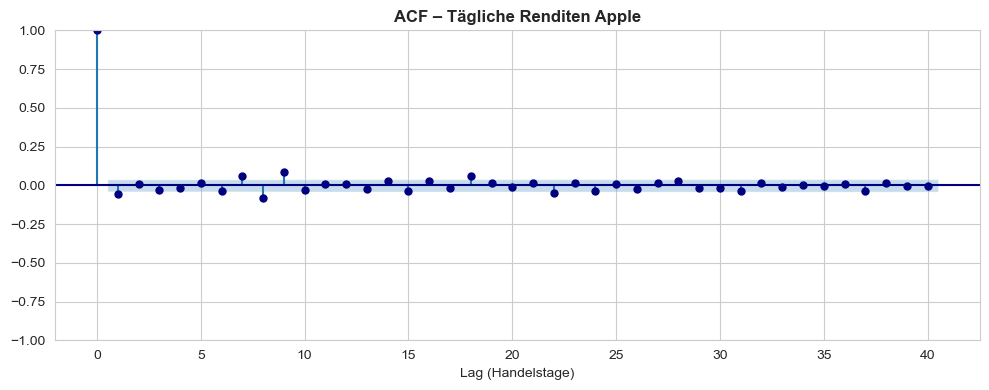

In [39]:
# ── 4. ACF der täglichen Renditen ────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(apple_returns.dropna(), lags=40, ax=ax, alpha=0.05, color="navy")
ax.set_title("ACF – Tägliche Renditen Apple", fontsize=12, weight="bold")
ax.set_xlabel("Lag (Handelstage)")
plt.tight_layout()
plt.show()

**ACF der Renditen:** Die Autokorrelationen liegen nahezu vollständig im Konfidenzintervall — die Renditen sind weitgehend unkorreliert und damit schwer vorhersagbar, was konsistent mit der Efficient Market Hypothesis ist.

## Weather

Verteilung, saisonale Streuung und tägliche Temperaturdifferenzen als Grundlage
für die anschließende Zeitreihenanalyse.

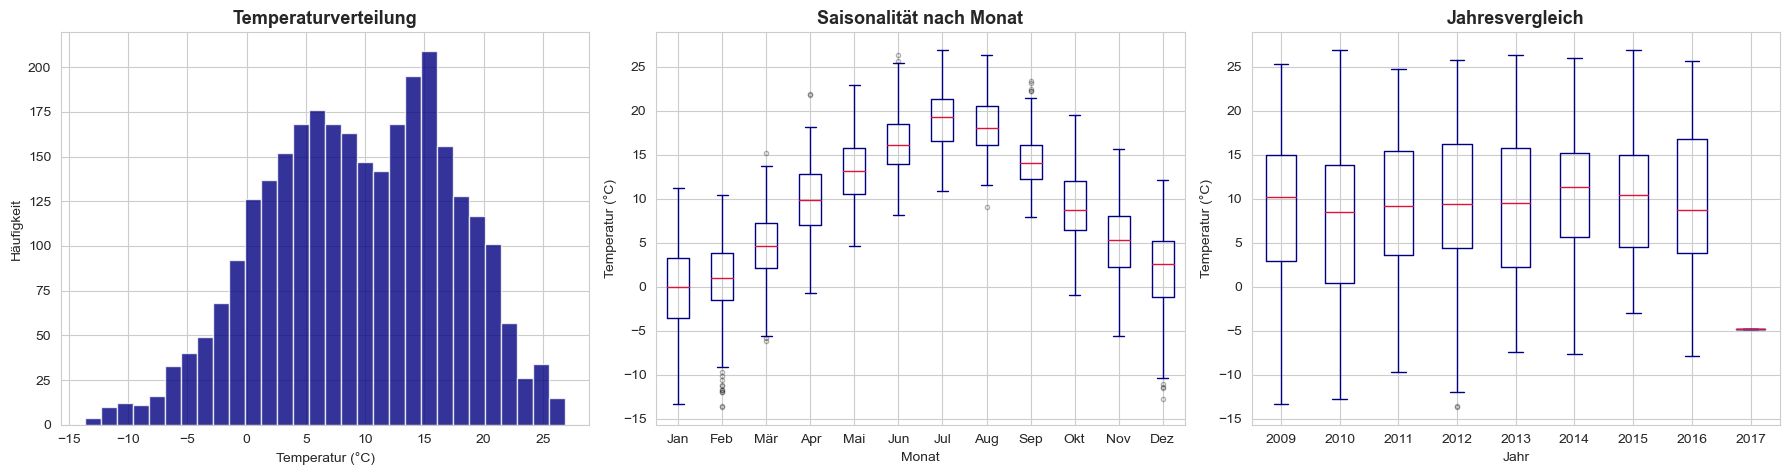

In [40]:
weather_daily = df_weather["T (degC)"].resample("D").mean().to_frame()
weather_daily["month"] = weather_daily.index.month
weather_daily["year"] = weather_daily.index.year

month_map = {1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"}
weather_daily["month_name"] = pd.Categorical(
    weather_daily["month"].map(month_map),
    categories=list(month_map.values()),
    ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramm – Gesamtverteilung der Tagestemperaturen
axes[0].hist(weather_daily["T (degC)"].dropna(), bins=30, color="navy", alpha=0.8)
axes[0].set_title("Temperaturverteilung", fontsize=13, weight="bold")
axes[0].set_xlabel("Temperatur (°C)")
axes[0].set_ylabel("Häufigkeit")

# Boxplot pro Monat – saisonale Streuung
weather_daily.boxplot(column="T (degC)", by="month_name", ax=axes[1],
                      boxprops=dict(color="navy"),
                      medianprops=dict(color="crimson"),
                      whiskerprops=dict(color="navy"),
                      capprops=dict(color="navy"),
                      flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[1].set_title("Saisonalität nach Monat", fontsize=13, weight="bold")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Temperatur (°C)")
fig.suptitle("")

# Boxplot pro Jahr – jahresübergreifender Vergleich
weather_daily.boxplot(column="T (degC)", by="year", ax=axes[2],
                      boxprops=dict(color="navy"),
                      medianprops=dict(color="crimson"),
                      whiskerprops=dict(color="navy"),
                      capprops=dict(color="navy"),
                      flierprops=dict(marker="o", color="navy", alpha=0.3, markersize=3))
axes[2].set_title("Jahresvergleich", fontsize=13, weight="bold")
axes[2].set_xlabel("Jahr")
axes[2].set_ylabel("Temperatur (°C)")
fig.suptitle("")

plt.tight_layout()
plt.show()

## Erkenntnisse
**Temperaturverteilung:** Die Tagestemperaturen sind annähernd normalverteilt mit einem
leichten rechtsseitigen Schwerpunkt um ~15°C. Der Großteil der Werte liegt zwischen 0°C
und 20°C, Extremwerte reichen von –15°C bis +25°C.

**Saisonalität:** Die Monatsboxplots zeigen einen klaren saisonalen Zyklus. Die Wintermonate
Januar und Februar liegen im Median unter 0°C mit hoher Streuung, die Sommermonate Juli
und August erreichen Medianwerte um ~19°C. Die größte Streuung tritt in den
Übergangsmonaten März und Oktober auf — typisch für kontinentales Klima.

**Jahresvergleich:** Die Mediantemperaturen sind über die Jahre 2009–2016 weitgehend stabil
(~8–10°C). Auffällig ist 2012 mit einem negativen Ausreißer (~–15°C), was mit dem im
Zeitreihenverlauf bereits identifizierten Kälteeinbruch übereinstimmt. 2017 ist aufgrund
unvollständiger Daten (nur Januar) nicht repräsentativ.

## Weather – Autokorrelationsanalyse (ACF)

Die ACF der täglichen Durchschnittstemperatur zeigt die zeitliche Abhängigkeitsstruktur
der Zeitreihe. Der langsame Abfall der Autokorrelationen bestätigt starke saisonale
Persistenz und gibt Hinweise auf die Lag-Auswahl für die ARMA-Modellierung.

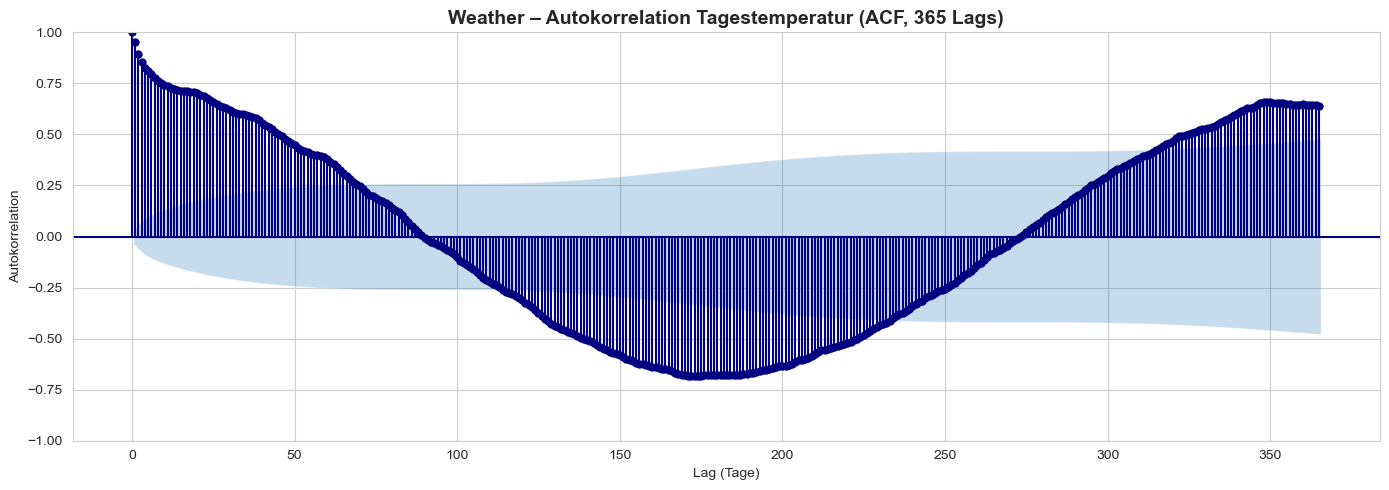

In [41]:
weather_daily = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("D")
    .mean()
    .dropna()
)

fig, ax = plt.subplots()
plot_acf(weather_daily, lags=365, alpha=0.05, ax=ax, color="navy", vlines_kwargs={"colors": "navy"})
ax.set_title("Weather – Autokorrelation Tagestemperatur (ACF, 365 Lags)", fontsize=14, weight="bold")
ax.set_xlabel("Lag (Tage)")
ax.set_ylabel("Autokorrelation")
plt.tight_layout()
plt.show()

## Erkenntnisse – Autokorrelationsanalyse (ACF)

Die ACF zeigt einen klaren sinusförmigen Verlauf über 365 Lags — das Paradebeispiel
einer saisonalen Zeitreihe. Die Autokorrelation fällt von ~0.95 bei Lag 1 kontinuierlich
ab, unterschreitet das Konfidenzband bei ~Lag 90, erreicht ihr Minimum von ~–0.75 bei
Lag ~180 (halbes Jahr, entgegengesetzte Jahreszeit) und steigt anschließend wieder auf
~0.65 bei Lag 365 an (gleiche Jahreszeit im Folgejahr).

Dieser Verlauf bestätigt zwei Dinge: erstens die starke kurzfristige Persistenz der
Temperatur, zweitens die ausgeprägte jährliche Saisonalität. Die durchgehend
signifikanten Autokorrelationen außerhalb des Konfidenzbands belegen die
Nichtstationarität der Rohreihe — die differenzierte Reihe ist für die ARMA-Modellierung
vorzuziehen.

## Tägliche Temperaturdifferenz (Wachstumsrate)

Differenzenbildung nach $g_t = x_t - x_{t-1}$ . Stationäre Schwankungen
um 0 deuten darauf hin, dass die differenzierte Reihe keine systematischen Trends aufweist —
relevante Voraussetzung für ARMA-Modellierung.

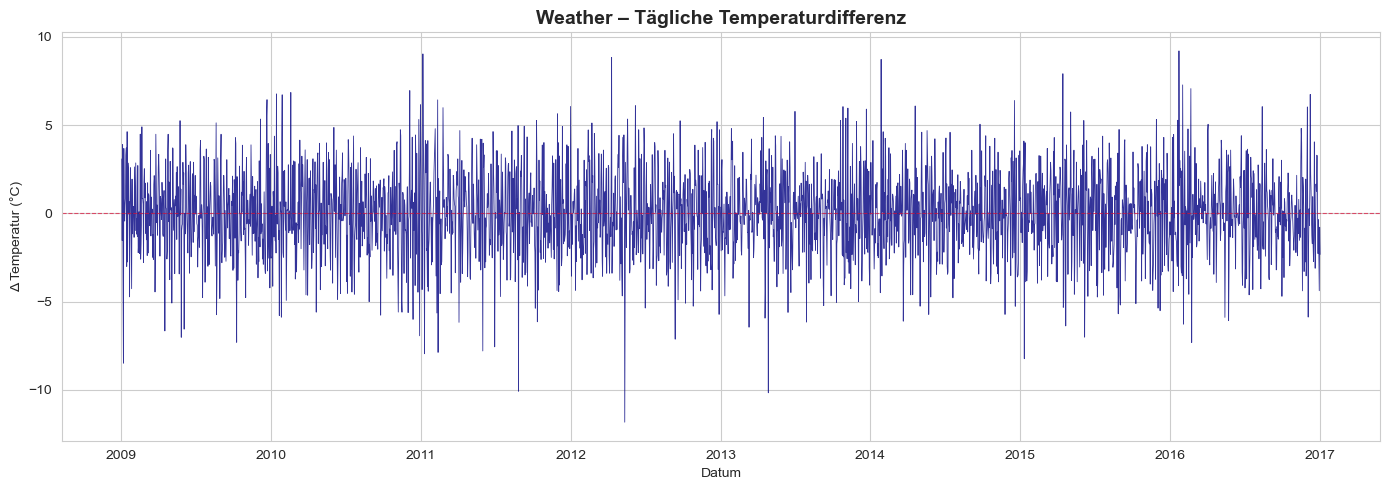

In [42]:
# Tägliche Differenz der Durchschnittstemperatur
temp_diff = df_weather["T (degC)"].resample("D").mean().diff().dropna()

fig, ax = plt.subplots()
ax.plot(temp_diff.index, temp_diff.values, color="navy", linewidth=0.6, alpha=0.8)
ax.axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)
ax.set_title("Weather – Tägliche Temperaturdifferenz", fontsize=14, weight="bold")
ax.set_ylabel("Δ Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Erkenntnisse – Tägliche Temperaturdifferenz

Die täglichen Temperaturdifferenzen schwanken stationär um 0°C mit einer typischen
Tagesänderung von ±2–3°C. Einzelne Ausreißer bis ±10°C markieren abrupte Wetterlagen.
Das Fehlen eines systematischen Trends oder einer Saisonalität in der differenzierten Reihe
bestätigt, dass die Differenzenbildung die Nichtstationarität der Rohdaten erfolgreich beseitigt —
eine zentrale Voraussetzung für die ARMA-Modellierung.